# 다이캐스팅 공정 데이터 분석 — Product_Type 1
> **분석 대상**: Product_Type 1 전용 (Type 2 완전 제외)

> **구성**: 데이터 로드 → 중복 제거 → 결측값 처리 → 이상치 처리 → 타겟/파생변수 → 시각화 → 상관분석 → 모델링

> **이상치 처리 합의 (260303)**
> - Velocity=0 → 삭제
> - Cycle_Time 극단값 → 공정 지연 신호로 유지
> - 절사 기준 IQR / 1% / 0.5% 비교
> - Velocity_2 이상치 184건 → 추가 조사 중

> **SMOTE 미적용** — class_weight로 불균형 대응

## STEP 0. 라이브러리 임포트 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 (멀티헤더)
df_raw = pd.read_csv(
    "../../data/DieCasting_Quality_Raw_Data.csv",
    header=[0, 1]
)
print(f"원본 Shape: {df_raw.shape}")
df_raw.head(3)

원본 Shape: (7535, 57)


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144       0.17      0.188         2.134   
1    1002            1    2      0.144       0.17      0.182         2.124   
2    2003            1    3      0.144       0.17      0.182         2.116   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  

[3 rows x 57 columns]

## STEP 1. 데이터 구조 파악

In [2]:
print("컬럼 그룹:", df_raw.columns.get_level_values(0).unique().tolist())
print(f"전체 컬럼 수: {len(df_raw.columns)}")
df_raw.info()

컬럼 그룹: ['Process', 'Sensor', 'Defects']
전체 컬럼 수: 57
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float6

In [3]:
df_raw.describe()

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  7.535000e+03  7535.000000  7535.000000  7535.000000  7535.000000   
mean   3.767454e+06     1.441672   453.798938     0.148219     0.168801   
std    2.175264e+06     0.496619   319.451698     0.007134     0.004720   
min    1.000000e+00     1.000000     0.000000     0.134000     0.158000   
25%    1.883893e+06     1.000000   195.000000     0.142000     0.166000   
50%    3.767193e+06     1.000000   401.000000     0.144000     0.168000   
75%    5.650924e+06     2.000000   645.000000     0.156000     0.170000   
max    7.534661e+06     2.000000  1296.000000     0.180000     0.212000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  7535.000000   7535.000000       7535.000000     7535.000000   
mean      0.191193      2.319210        239.655607        0.009596   
std       0.011563      0.222041         23.305451        0.002148   
min       0.172000      0.000000        107.000000        0.000000   
25%       0.181000      2.134000        217.000000        0.008000   
50%       0.188000      2.161000        239.000000        0.009000   
75%       0.202000      2.523000        265.000000        0.012000   
max       0.234000      2.744000        266.000000        0.021000   

                          ...      Defects                                     \
      Biscuit_Thickness   ...  Blow_Hole_2 Stain_2       Dent_2 Deformation_2   
count        7535.000000  ...  7535.000000  7535.0  7535.000000   7535.000000   
mean           14.309622  ...     0.021367     0.0     0.000531      0.008626   
std             3.286284  ...     0.150020     0.0     0.023036      0.093907   
min             0.000000  ...     0.000000     0.0     0.000000      0.000000   
25%            11.000000  ...     0.000000     0.0     0.000000      0.000000   
50%            13.000000  ...     0.000000     0.0     0.000000      0.000000   
75%            17.000000  ...     0.000000     0.0     0.000000      0.000000   
max            24.000000  ...     2.000000     0.0     1.000000      2.000000   

                                                                         \
      Contamination_2   Impurity_2      Crack_2 Scratch_2 Buring_Mark_2   
count     7535.000000  7535.000000  7535.000000    7535.0        7535.0   
mean         0.001062     0.000664     0.000265       0.0           0.0   
std          0.032569     0.025753     0.016291       0.0           0.0   
min          0.000000     0.000000     0.000000       0.0           0.0   
25%          0.000000     0.000000     0.000000       0.0           0.0   
50%          0.000000     0.000000     0.000000       0.0           0.0   
75%          0.000000     0.000000     0.000000       0.0           0.0   
max          1.000000     1.000000     1.000000       0.0           0.0   

                    
      Inclusions_2  
count  7535.000000  
mean      0.000133  
std       0.011520  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  

[8 rows x 57 columns]

In [4]:
df_raw.nunique()

Process  id                      7535
         Product_Type               2
         Shot                    1271
         Velocity_1                33
         Velocity_2                27
         Velocity_3                45
         High_Velocity            319
         Cylinder_Pressure         22
         Rapid_Rise_Time           18
         Biscuit_Thickness         24
         Clamping_Force            42
         Cycle_Time                61
          Pressure_Rise_Time       16
         Casting_Pressure          65
         Spray_Time                32
         Spray_1_Time               7
         Spray_2_Time               8
Sensor   Melting_Furnace_Temp     737
         Air_Pressure              26
         Air_Pressure_Min           1
         Air_Pressure_Max           1
         Coolant_Temp              23
         Coolant_Temp_Min           1
         Coolant_Temp_Max           1
         Coolant_Pressure          22
         Factory_Temp              67
         Fac

## STEP 2. 헤더 정리 & Product_Type 1 필터링
> 멀티헤더 → 단일헤더 변환 후 **Product_Type 1만 추출**

In [5]:
df = df_raw.copy()

# 멀티헤더 → 단일헤더
df.columns = df.columns.get_level_values(1).str.strip()

# 수치형 변환
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# ── Product_Type 1만 추출
df = df[df['Product_Type'] == 1].reset_index(drop=True)

print(f"✅ Product_Type 1 추출 완료: {df.shape[0]}행 × {df.shape[1]}열")
print(f"   전체 대비: {df.shape[0]}/7535행 ({df.shape[0]/7535*100:.1f}%)")

✅ Product_Type 1 추출 완료: 4207행 × 57열
   전체 대비: 4207/7535행 (55.8%)


## STEP 3. 중복 데이터 확인 및 제거
> id 제외 기준 완전 중복 행 탐지 후 제거

> **판단 근거**: Cavity 정보는 이미 _1/_2 컬럼으로 하나의 행에 통합되어 있어
> 완전 중복 행은 데이터 수집 오기로 판단

In [6]:
print(f"중복 제거 전: {df.shape[0]}행")
print(f"id 제외 중복 행 수: {df.drop(columns=['id']).duplicated().sum()}건")

# 중복 중 불량/양품 분포 확인
defect_cols_check = [c for c in df.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
dup_mask = df.drop(columns=['id']).duplicated(keep=False)
dup_rows = df[dup_mask]
print(f"중복 행 중 불량: {(dup_rows[defect_cols_check].sum(axis=1)>0).sum()}건")
print(f"중복 행 중 양품: {(dup_rows[defect_cols_check].sum(axis=1)==0).sum()}건")

중복 제거 전: 4207행
id 제외 중복 행 수: 1554건
중복 행 중 불량: 326건
중복 행 중 양품: 2782건


In [7]:
# 중복 제거 (첫 번째 행 유지)
before = df.shape[0]
dedup_cols = [c for c in df.columns if c != 'id']
df = df.drop_duplicates(subset=dedup_cols, keep='first').reset_index(drop=True)

print(f"✅ 중복 제거 완료")
print(f"   제거 전: {before}행 → 제거 후: {df.shape[0]}행 (제거: {before - df.shape[0]}건)")

✅ 중복 제거 완료
   제거 전: 4207행 → 제거 후: 2653행 (제거: 1554건)


## STEP 4. 결측값 확인 및 처리

In [8]:
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) == 0:
    print("결측값 없음")
else:
    print("결측값 보유 컬럼:")
    display(pd.DataFrame({'missing_count': missing_cols,
                          'missing_ratio(%)': (missing_cols/len(df)*100).round(2)}))

결측값 없음


In [9]:
# Factory 센서 결측값 → 중앙값 대체 (Product_Type 1 단일이므로 전체 중앙값 사용)
factory_cols = [
    'Factory_Temp','Factory_Temp_Min','Factory_Temp_Max',
    'Factory_Humidity','Factory_Humidity_Min','Factory_Humidity_Max'
]
for col in factory_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f"✅ 결측값 처리 완료 → 잔여 결측값: {df.isnull().sum().sum()}건")

✅ 결측값 처리 완료 → 잔여 결측값: 0건


## STEP 5. 이상치 탐지 및 처리
> **처리 순서**
> 1. 분산=0 변수 사전 확인 → Capping 대상에서 제외 (IQR=0이면 과도한 Capping 발생)
> 2. Velocity=0 → 삭제
> 3. Cycle_Time → Capping 제외 (공정 지연 신호)
> 4. 절사 기준 IQR / 1% / 0.5% 비교 후 IQR 적용
> 5. Velocity_2 이상치 → 추가 조사 중 (IQR 유지)

In [10]:
# 이상치 탐지 함수(iqr)

def detect_outliers_iqr(dataframe, cols):
    outlier_info = {}
    for col in cols:
        Q1, Q3 = dataframe[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 3.0*IQR, Q3 + 3.0*IQR
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        outlier_info[col] = {
            'count': mask.sum(),
            'pct(%)': f"{mask.mean()*100:.2f}",
            'lower_bound': round(lower, 3),
            'upper_bound': round(upper, 3)
        }
    result = pd.DataFrame(outlier_info).T.sort_values('count', ascending=False)
    return result[result['count'] > 0]

process_num_cols = [
    'Velocity_1','Velocity_2','Velocity_3','High_Velocity',
    'Cylinder_Pressure','Rapid_Rise_Time','Biscuit_Thickness',
    'Clamping_Force','Cycle_Time','Pressure_Rise_Time',
    'Casting_Pressure','Spray_Time','Spray_1_Time','Spray_2_Time'
]

# ── 분산=0 또는 IQR=0 변수 사전 확인 → Capping 대상에서 제외
zero_var_cols = []
for col in process_num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    if df[col].std() == 0 or df[col].nunique() <= 1 or IQR == 0:
        zero_var_cols.append(col)

if zero_var_cols:
    print(f"⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: {zero_var_cols}")
    for col in zero_var_cols:
        print(f"   {col}: 고유값={df[col].nunique()}, IQR={df[col].quantile(0.75)-df[col].quantile(0.25):.4f}")
else:
    print("✅ 분산=0 / IQR=0 변수 없음")

# Capping 가능한 컬럼만 추출 (IQR=0 + Cycle_Time 제외)
cap_cols = [c for c in process_num_cols if c != 'Cycle_Time' and c not in zero_var_cols]
print(f"\nCapping 대상 컬럼 ({len(cap_cols)}개): {cap_cols}")

print("\n[ Process 변수 이상치 탐지 (IQR=0 제외) ]")
display(detect_outliers_iqr(df, cap_cols))
print("\n※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)")
print("※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)")
if zero_var_cols:
    print(f"※ {zero_var_cols} → IQR=0으로 Capping 제외 (이후 피처에서도 제거)")

⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: ['Rapid_Rise_Time', 'Spray_2_Time']
   Rapid_Rise_Time: 고유값=18, IQR=0.0000
   Spray_2_Time: 고유값=3, IQR=0.0000

Capping 대상 컬럼 (11개): ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Biscuit_Thickness', 'Clamping_Force', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time']

[ Process 변수 이상치 탐지 (IQR=0 제외) ]


,count,pct(%),lower_bound,upper_bound
Cylinder_Pressure,357,13.46,206.0,227.0
Casting_Pressure,357,13.46,991.0,1103.0
Spray_Time,313,11.80,6.7,9.5
Velocity_2,72,2.71,0.162,0.176
Velocity_1,70,2.64,0.136,0.15
Biscuit_Thickness,52,1.96,8.0,15.0
High_Velocity,48,1.81,2.029,2.246
Velocity_3,33,1.24,0.157,0.206
Clamping_Force,3,0.11,242.0,270.0
Pressure_Rise_Time,2,0.08,0.032,0.053



※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)
※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)
※ ['Rapid_Rise_Time', 'Spray_2_Time'] → IQR=0으로 Capping 제외 (이후 피처에서도 제거)


In [11]:
# Velocity=0 삭제 (도메인 상 불가능한 값)
zero_mask = (df['High_Velocity'] == 0)
print(f"Velocity=0 행 삭제: {zero_mask.sum()}건")
df = df[~zero_mask].reset_index(drop=True)

# 이상치 현황 확인 (탐지만, 제거/Capping 미적용)
def count_outliers(dataframe, cols, method='iqr', pct=0.01):
    result = {}
    for col in cols:
        if method == 'iqr':
            Q1, Q3 = dataframe[col].quantile(0.25), dataframe[col].quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 3.0*IQR, Q3 + 3.0*IQR
        else:
            lower = dataframe[col].quantile(pct)
            upper = dataframe[col].quantile(1 - pct)
        result[col] = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
    return pd.Series(result)

compare_df = pd.DataFrame({
    'IQR':  count_outliers(df, cap_cols, 'iqr'),
    '1%':   count_outliers(df, cap_cols, 'pct', 0.01),
    '0.5%': count_outliers(df, cap_cols, 'pct', 0.005),
}).sort_values('IQR', ascending=False)

print("[ 절사 기준별 이상치 건수 비교 (참고용) ]")
print("※ 도메인 상 논리적이지 않은 값(Velocity=0)만 제거, 나머지 이상치는 유지")
display(compare_df[compare_df.sum(axis=1) > 0])
print(f"\n최종 데이터: {df.shape[0]}행 × {df.shape[1]}열")

Velocity=0 행 삭제: 2건
[ 절사 기준별 이상치 건수 비교 (참고용) ]
※ 도메인 상 논리적이지 않은 값(Velocity=0)만 제거, 나머지 이상치는 유지


,IQR,1%,0.5%
Cylinder_Pressure,355,8,8
Casting_Pressure,355,13,13
Spray_Time,313,38,23
Velocity_2,72,24,15
Velocity_1,70,37,24
Biscuit_Thickness,52,37,24
High_Velocity,46,53,28
Velocity_3,33,34,24
Clamping_Force,3,38,19
Pressure_Rise_Time,0,9,9



최종 데이터: 2651행 × 57열


## STEP 6. 타겟 변수 및 파생변수 생성
> 기존 `Pressure_Diff_ratio` + 신규 파생변수 7개 추가 (파생변수_정의.md 기반)

In [12]:
# 타겟 변수
defect_cols_all = [c for c in df.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
df['Defect_Status'] = (df[defect_cols_all].sum(axis=1) > 0).astype(int)

defect_types = {
    'Short_Shot':  ['Short_Shot_1','Short_Shot_2'],
    'Blow_Hole':   ['Blow_Hole_1','Blow_Hole_2'],
    'Exfoliation': ['Exfoliation_1','Exfoliation_2'],
    'Stain':       ['Stain_1','Stain_2'],
    'Deformation': ['Deformation_1','Deformation_2'],
    'Bubble':      ['Bubble_1','Bubble_2'],
    'Other': ['Dent_1','Dent_2','Contamination_1','Contamination_2',
              'Impurity_1','Impurity_2','Crack_1','Crack_2',
              'Scratch_1','Scratch_2','Buring_Mark_1','Buring_Mark_2',
              'Inclusions_1','Inclusions_2']
}

def get_defect_label(row):
    if row['Defect_Status'] == 0: return 'Normal'
    for label, cols in defect_types.items():
        valid = [c for c in cols if c in row.index]
        if row[valid].sum() > 0: return label
    return 'Other'

df['Defect_Type'] = df.apply(get_defect_label, axis=1)

print("✅ 타겟 변수 생성 완료")
print(f"\n[Defect_Status 분포]")
print(df['Defect_Status'].value_counts().to_string())
print(f"\n불량률: {df['Defect_Status'].mean()*100:.1f}%")
print(f"\n[Defect_Type 분포]")
print(df['Defect_Type'].value_counts().to_string())

✅ 타겟 변수 생성 완료

[Defect_Status 분포]
Defect_Status
0    2075
1     576

불량률: 21.7%

[Defect_Type 분포]
Defect_Type
Normal         2075
Exfoliation     196
Short_Shot      165
Deformation     152
Bubble           58
Other             3
Stain             2


In [13]:
# ── 기존 파생변수
df['Pressure_Diff_ratio'] = df['Casting_Pressure'] / df['Cylinder_Pressure']

# ── 신규 파생변수 (1순위)
df['clamp_per_press']   = df['Clamping_Force'] / df['Casting_Pressure']      # 클램핑력 / 캐스팅압력
df['temp_diff']         = df['Melting_Furnace_Temp'] - df['Factory_Temp']     # 용탕온도 - 공장온도

# ── 신규 파생변수 (2순위)
# Rapid_Rise_Time이 0인 경우 division 방지
df['press_time_ratio']  = df['Pressure_Rise_Time'] / df['Rapid_Rise_Time'].replace(0, np.nan)
df['spray_cycle_ratio'] = df['Spray_Time'] / df['Cycle_Time']
df['heat_index']        = df['Factory_Temp'] * df['Factory_Humidity'] / 100

# ── 신규 파생변수 (3순위)
df['vel_accel'] = df['Velocity_2'] - df['Velocity_1']                        # 1→2단계 속도 가속량
df['vel_ratio'] = df['Velocity_3'] / df['Velocity_2'].replace(0, np.nan)     # 2→3단계 속도 변화율

NEW_FEATURES = [
    'Pressure_Diff_ratio',
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index',
    'vel_accel', 'vel_ratio'
]

print("✅ 파생변수 생성 완료")
print(f"\n{'변수명':<22} {'결측값':>6}  {'평균':>10}  {'std':>10}")
print("-" * 55)
for col in NEW_FEATURES:
    print(f"  {col:<20} {df[col].isnull().sum():>6}  {df[col].mean():>10.4f}  {df[col].std():>10.4f}")

✅ 파생변수 생성 완료

변수명                       결측값          평균         std
-------------------------------------------------------
  Pressure_Diff_ratio       0      4.8400      0.0081
  clamp_per_press           0      0.2416      0.0080
  temp_diff                 0    666.3953     14.0255
  press_time_ratio          0      5.2958      0.7686
  spray_cycle_ratio         0      0.3904      0.0197
  heat_index                0     19.4199      1.6360
  vel_accel                 0      0.0256      0.0028
  vel_ratio                 0      1.0795      0.0265


In [14]:
from scipy import stats

# ── 파생변수 Spearman 상관계수 vs Defect_Status
print("[ 파생변수 Spearman 상관계수 vs Defect_Status ]")
print(f"\n{'변수명':<22} {'rho':>8}  {'p-value':>10}  {'유의':>6}")
print("-" * 55)

existing_rho = -0.115  # 기존 Pressure_Diff_ratio
rows = []
for col in NEW_FEATURES:
    valid = df[[col, 'Defect_Status']].dropna()
    rho, p = stats.spearmanr(valid[col], valid['Defect_Status'])
    sig = '✅' if p < 0.05 else '❌'
    rows.append({'변수': col, 'rho': round(rho, 4), 'p': round(p, 4)})
    print(f"  {col:<20} {rho:>+8.4f}  {p:>10.4f}  {sig}")

print(f"\n기존 Pressure_Diff_ratio rho: {existing_rho} (비교 기준)")

# 기존 원본 변수 상위 참고
print("\n[ 기존 원본 변수 상위 rho 참고 ]")
orig_cols = ['Factory_Humidity','Factory_Temp','Biscuit_Thickness','Spray_2_Time','Casting_Pressure']
for col in orig_cols:
    rho, _ = stats.spearmanr(df[col], df['Defect_Status'])
    print(f"  {col:<22} {rho:>+8.4f}")

[ 파생변수 Spearman 상관계수 vs Defect_Status ]

변수명                         rho     p-value      유의
-------------------------------------------------------
  Pressure_Diff_ratio   +0.0026      0.8936  ❌
  clamp_per_press       +0.1671      0.0000  ✅
  temp_diff             -0.1065      0.0000  ✅
  press_time_ratio      +0.0416      0.0321  ✅
  spray_cycle_ratio     -0.1007      0.0000  ✅
  heat_index            -0.3082      0.0000  ✅
  vel_accel             -0.0666      0.0006  ✅
  vel_ratio             +0.0029      0.8820  ❌

기존 Pressure_Diff_ratio rho: -0.115 (비교 기준)

[ 기존 원본 변수 상위 rho 참고 ]
  Factory_Humidity        -0.2782
  Factory_Temp            +0.2155
  Biscuit_Thickness       -0.1698
  Spray_2_Time            +0.1669
  Casting_Pressure        -0.1252


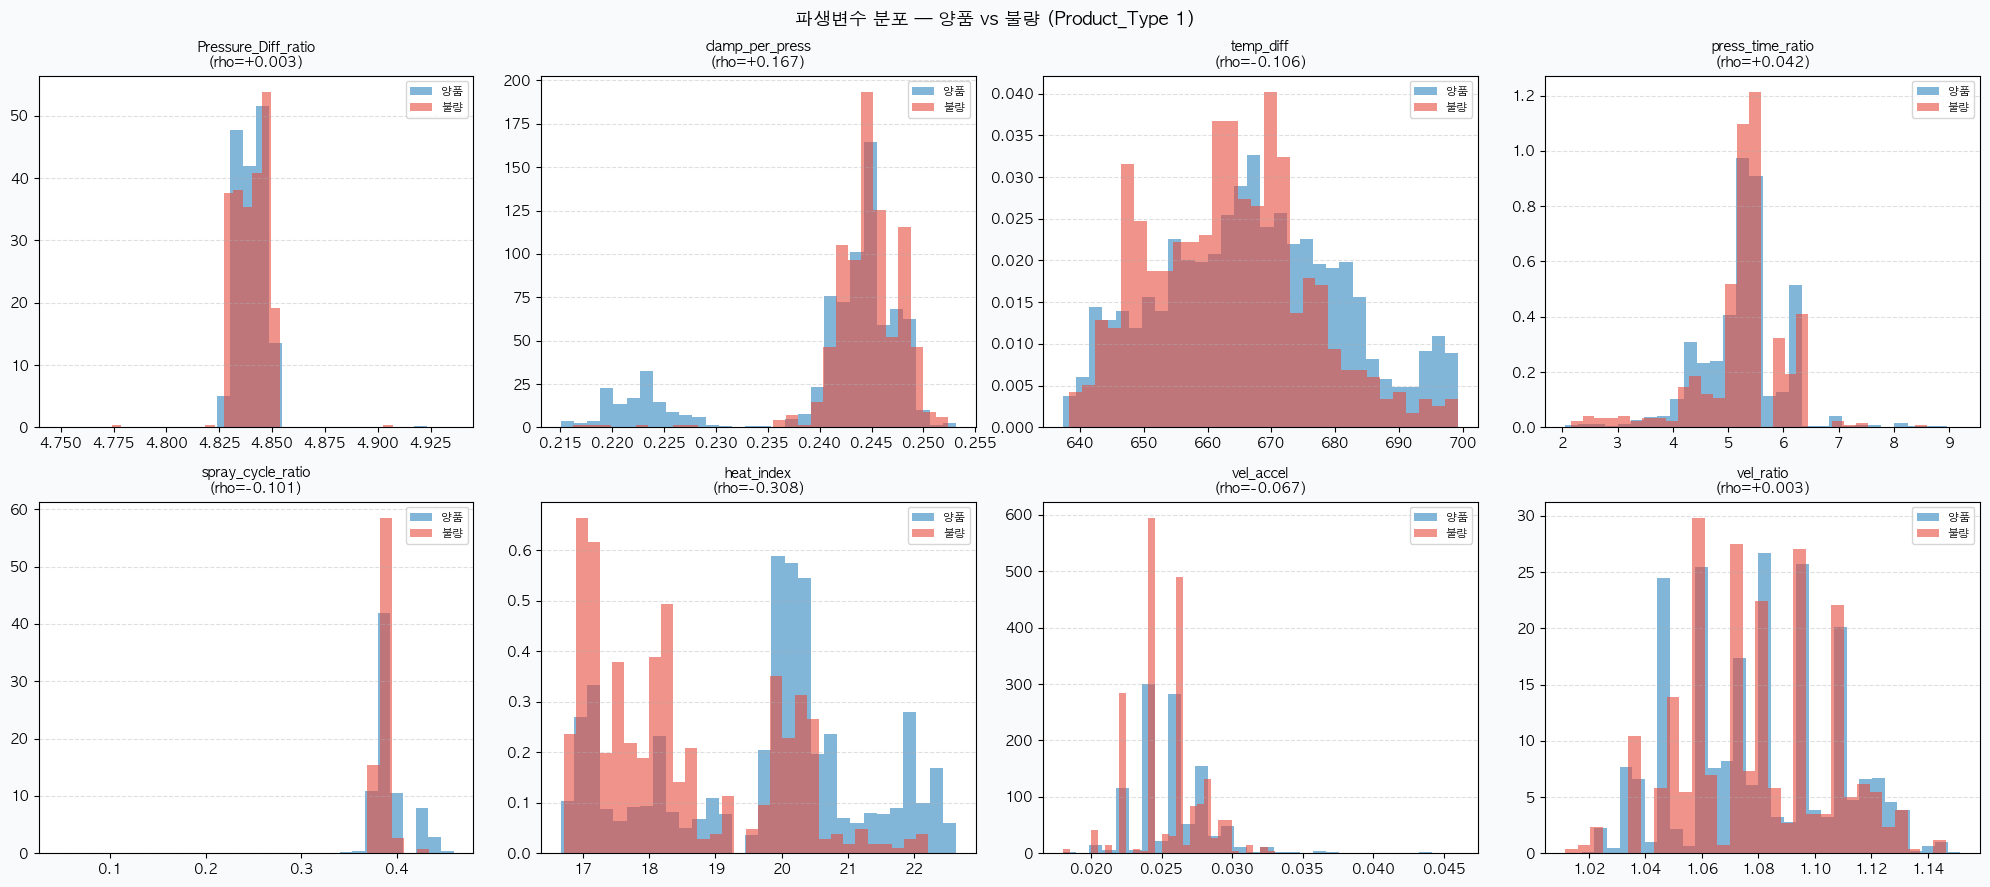

In [15]:
# ── 파생변수 분포 시각화 (양품 vs 불량)
fig, axes = plt.subplots(2, 4, figsize=(20, 9), facecolor='#F8FAFB')
axes = axes.flatten()

colors = {'양품': '#2E86C1', '불량': '#E74C3C'}

for i, col in enumerate(NEW_FEATURES):
    good = df[df['Defect_Status'] == 0][col].dropna()
    bad  = df[df['Defect_Status'] == 1][col].dropna()
    rho, _ = stats.spearmanr(df[col].dropna(), df.loc[df[col].notna(), 'Defect_Status'])

    axes[i].hist(good, bins=30, alpha=0.6, color=colors['양품'], label='양품', density=True)
    axes[i].hist(bad,  bins=30, alpha=0.6, color=colors['불량'], label='불량', density=True)
    axes[i].set_title(f'{col}\n(rho={rho:+.3f})', fontweight='bold', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('파생변수 분포 — 양품 vs 불량 (Product_Type 1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 7. 변수별 분포 시각화

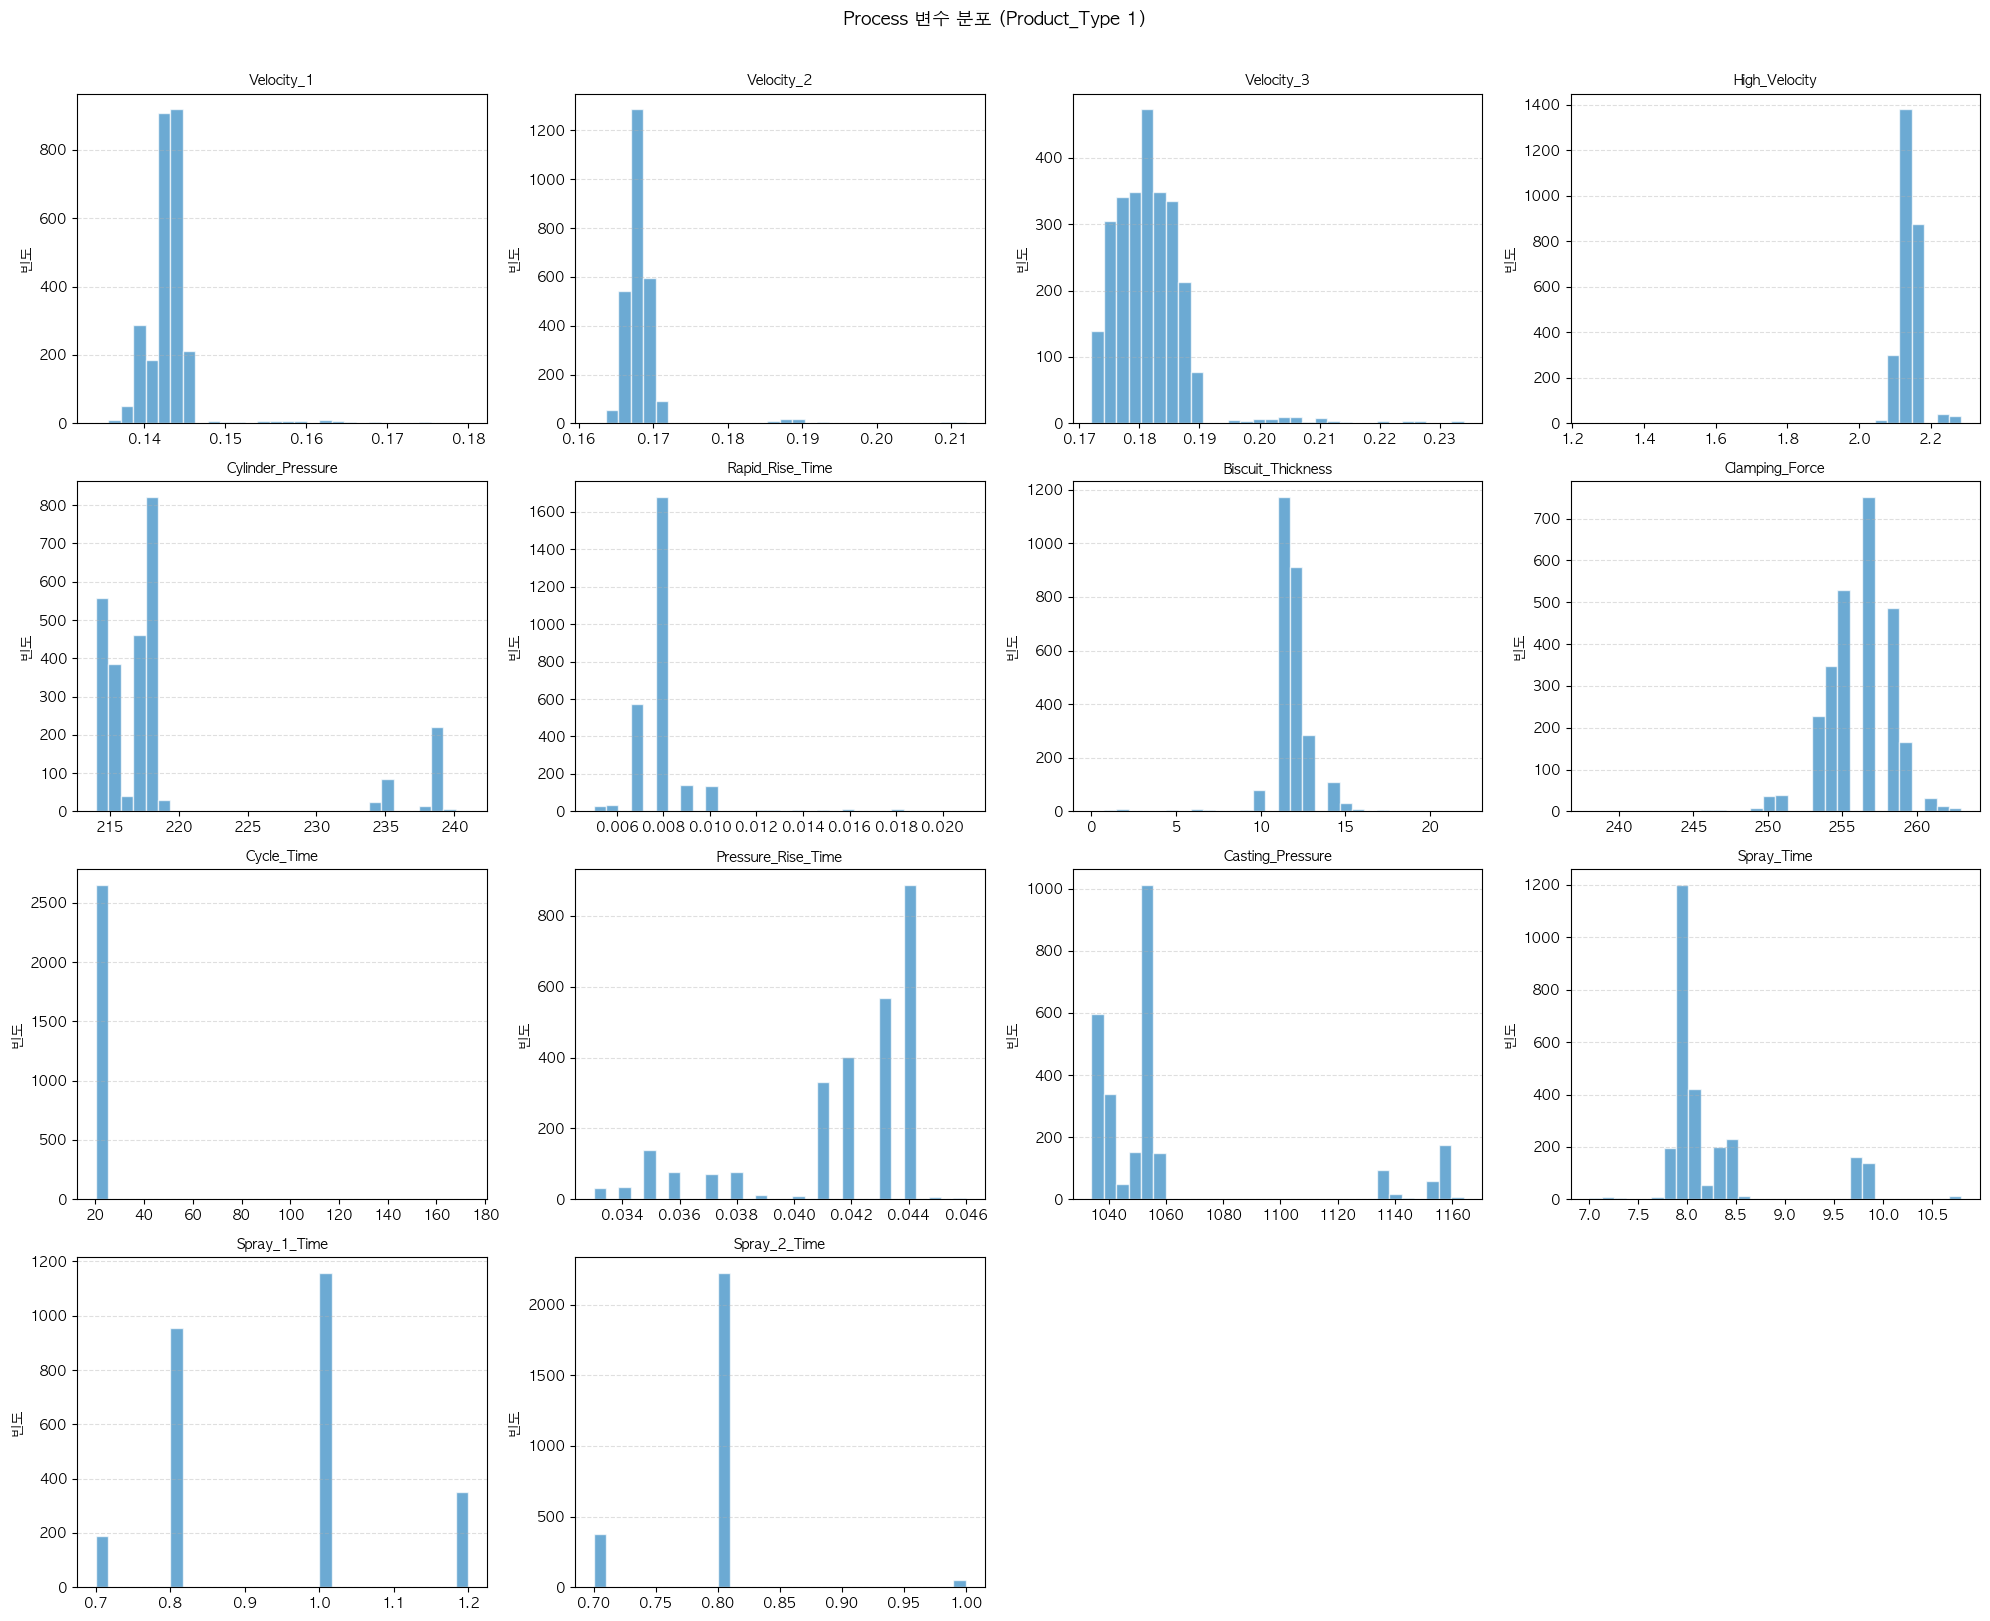

In [16]:
# Process 변수 히스토그램 + 박스플롯
n_cols, n_rows = 4, (len(process_num_cols) + 3) // 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(process_num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Process 변수 분포 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

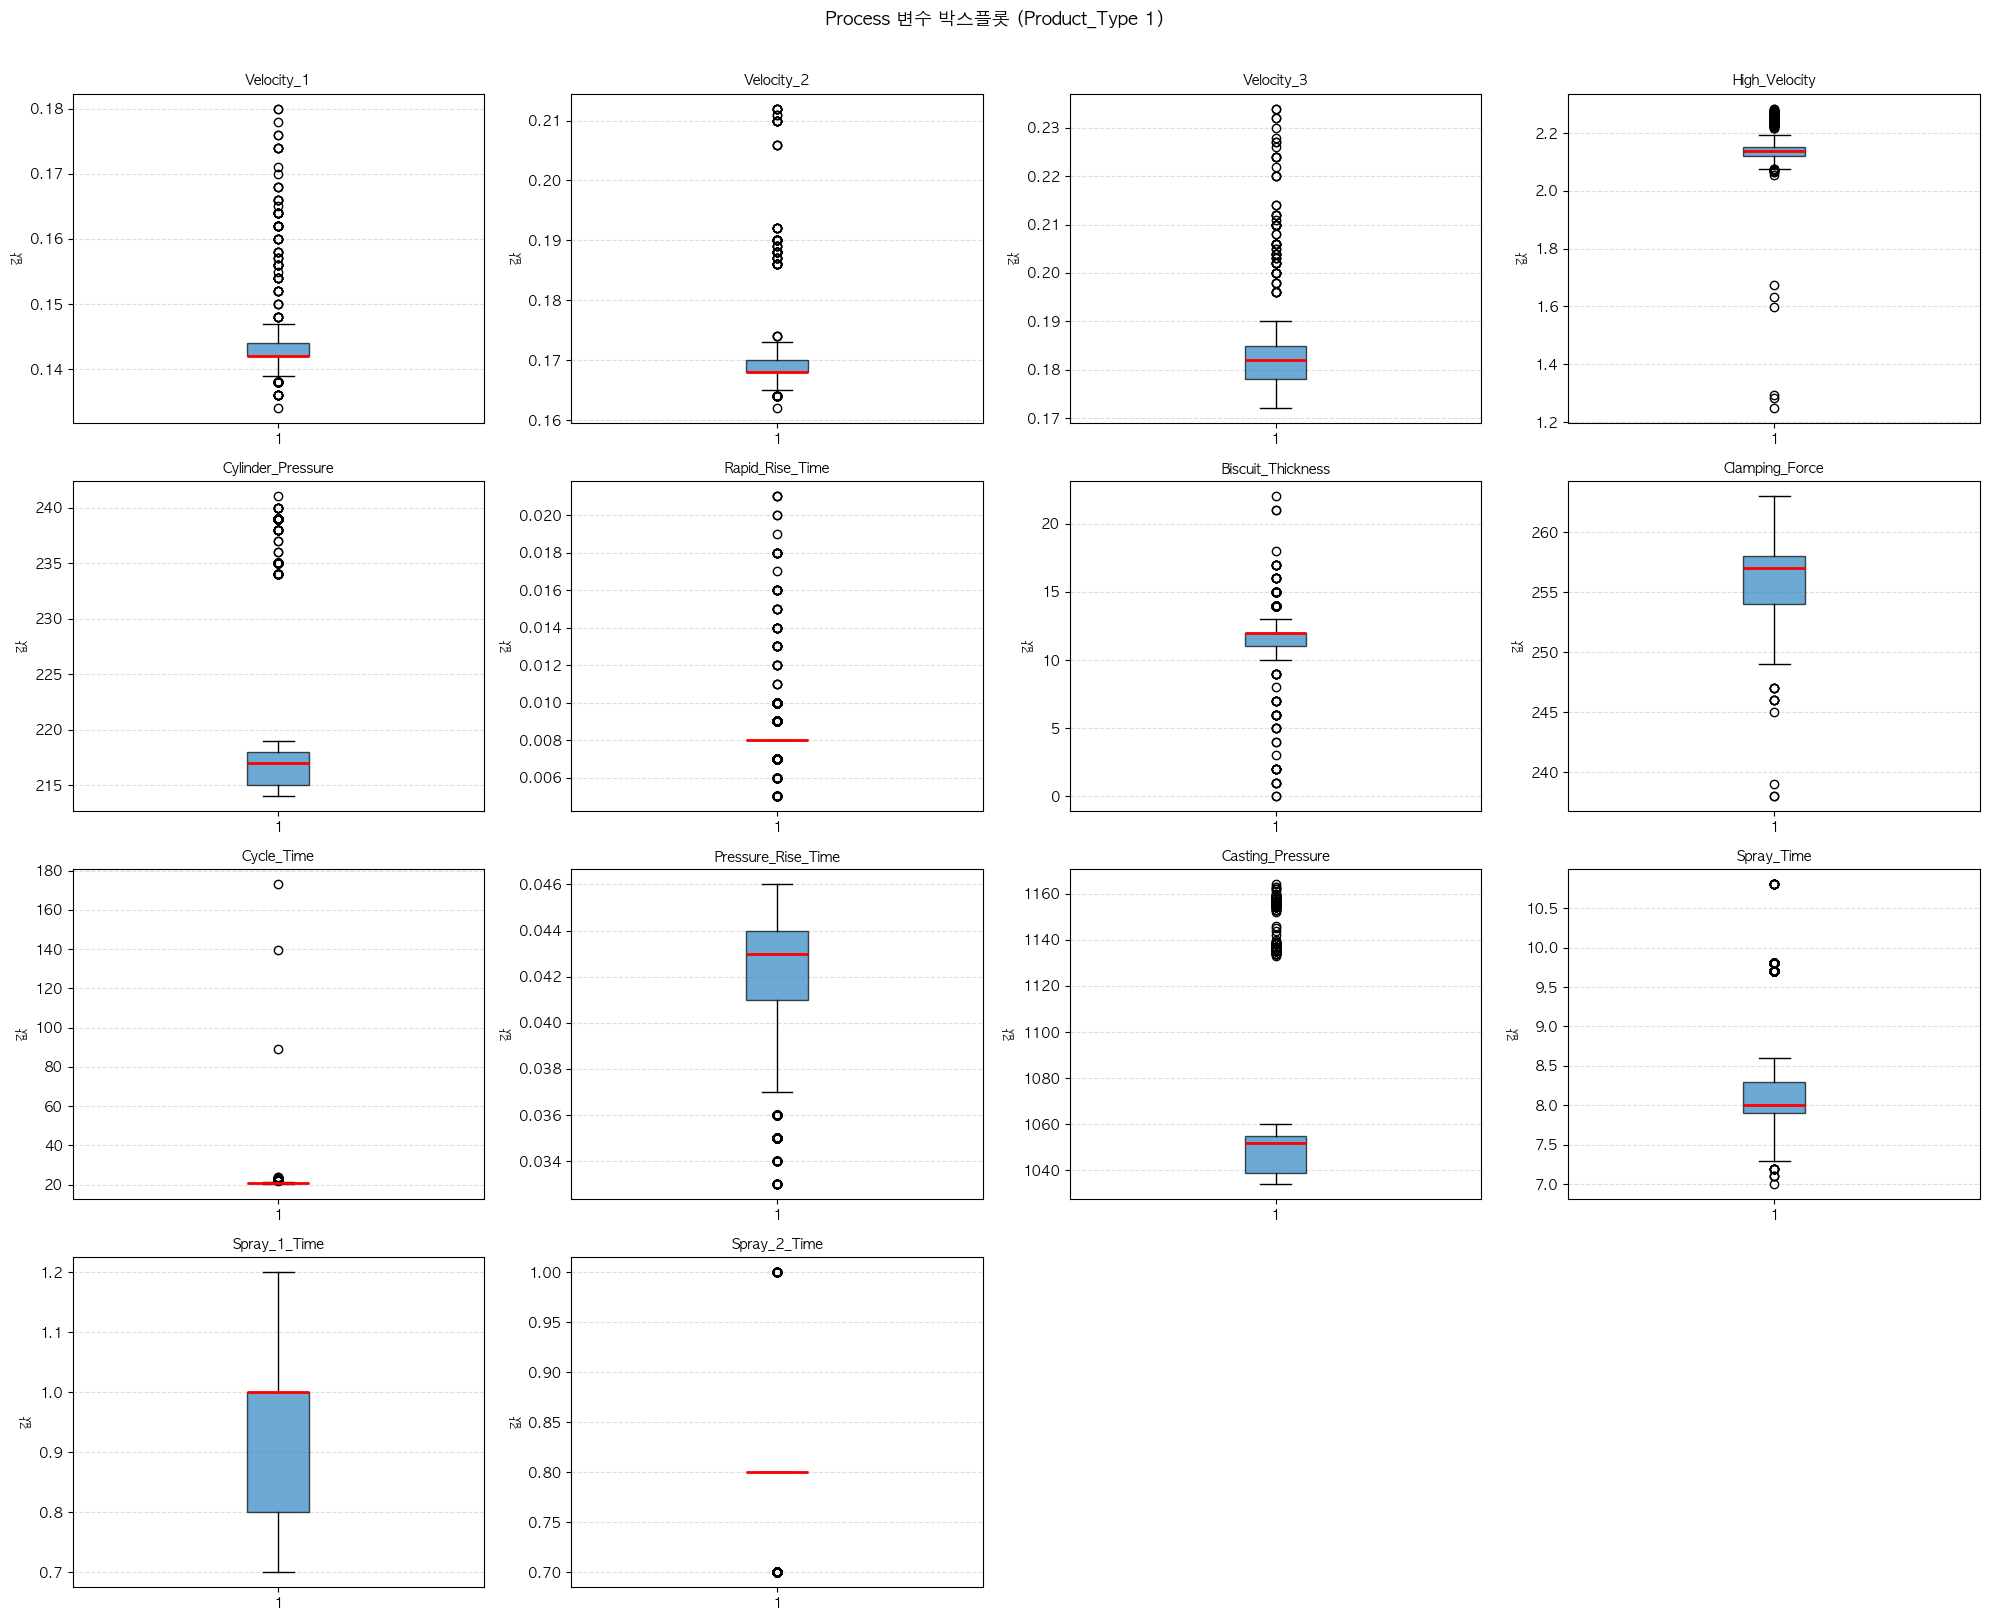

In [17]:
# Process 변수 박스플롯
n_cols, n_rows = 4, (len(process_num_cols) + 3) // 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(process_num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#2E86C1', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('값')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Process 변수 박스플롯 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [18]:
save_cols = (
    ['id', 'Product_Type', 'Shot']
    + process_num_cols
    + ['Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity']
    + NEW_FEATURES
    + ['Defect_Status', 'Defect_Type']
)

df_with_features = df[save_cols].copy()
df_with_features.to_csv('../../data/df_type1_파생변수추가.csv', index=False)

print(f"✅ 저장 완료: data/df_type1_파생변수추가.csv")
print(f"   Shape: {df_with_features.shape[0]}행 × {df_with_features.shape[1]}열")
print(f"   원본({25}열) 대비 파생변수 {len(NEW_FEATURES)}개 추가")
print(f"\n[ 컬럼 목록 ]")
for i, col in enumerate(df_with_features.columns, 1):
    marker = ' ← 신규' if col in NEW_FEATURES and col != 'Pressure_Diff_ratio' else ''
    print(f"  {i:2d}. {col}{marker}")
df_with_features.head(3)

✅ 저장 완료: data/df_type1_파생변수추가.csv
   Shape: 2651행 × 33열
   원본(25열) 대비 파생변수 8개 추가

[ 컬럼 목록 ]
   1. id
   2. Product_Type
   3. Shot
   4. Velocity_1
   5. Velocity_2
   6. Velocity_3
   7. High_Velocity
   8. Cylinder_Pressure
   9. Rapid_Rise_Time
  10. Biscuit_Thickness
  11. Clamping_Force
  12. Cycle_Time
  13. Pressure_Rise_Time
  14. Casting_Pressure
  15. Spray_Time
  16. Spray_1_Time
  17. Spray_2_Time
  18. Melting_Furnace_Temp
  19. Air_Pressure
  20. Coolant_Temp
  21. Coolant_Pressure
  22. Factory_Temp
  23. Factory_Humidity
  24. Pressure_Diff_ratio
  25. clamp_per_press ← 신규
  26. temp_diff ← 신규
  27. press_time_ratio ← 신규
  28. spray_cycle_ratio ← 신규
  29. heat_index ← 신규
  30. vel_accel ← 신규
  31. vel_ratio ← 신규
  32. Defect_Status
  33. Defect_Type


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Pressure_Diff_ratio,clamp_per_press,temp_diff,press_time_ratio,spray_cycle_ratio,heat_index,vel_accel,vel_ratio,Defect_Status,Defect_Type
0,1,1,1,0.144,0.17,0.188,2.134,214,0.008,10,...,4.845794,0.248795,662.1,5.500,0.376812,19.2136,0.026,1.105882,0,Normal
1,1002,1,2,0.144,0.17,0.182,2.124,217,0.008,11,...,4.847926,0.244297,663.5,5.500,0.376812,19.1478,0.026,1.070588,0,Normal
2,2003,1,3,0.144,0.17,0.182,2.116,214,0.008,11,...,4.845794,0.247830,663.5,5.125,0.375000,19.1478,0.026,1.070588,0,Normal


## STEP 8. 전처리 완료 데이터 저장

In [19]:
save_cols = (
    ['id','Product_Type','Shot']
    + process_num_cols
    + ['Melting_Furnace_Temp','Air_Pressure','Coolant_Temp',
       'Coolant_Pressure','Factory_Temp','Factory_Humidity']
    + ['Defect_Status','Defect_Type']
)
df_clean = df[save_cols].copy()
df_clean.to_csv('df_final_Type1_파생변수추가.csv', index=False)

print(f"✅ 저장 완료: df_final_Type1_파생변수추가.csv")
print(f"   최종 Shape: {df_clean.shape[0]}행 × {df_clean.shape[1]}열")
df_clean.head(3)

✅ 저장 완료: df_final_Type1_파생변수추가.csv
   최종 Shape: 2651행 × 25열


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Defect_Status,Defect_Type
0,1,1,1,0.144,0.17,0.188,2.134,214,0.008,10,...,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0,Normal
1,1002,1,2,0.144,0.17,0.182,2.124,217,0.008,11,...,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,Normal
2,2003,1,3,0.144,0.17,0.182,2.116,214,0.008,11,...,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,Normal
